# Exploratory Data Analysis — Indonesian Hoax Headline Detection

Dataset: **turnbackhoax.csv** (hoax/factual labels via `[PREFIX]`) + **detik.csv** (all factual).

**Scope:**
1. Raw data — shape, missing, category, date, title length, label extraction stats
2. Processed data — class balance & text length per split (pipeline A & B)
3. Cross-split leakage check

Run preprocessing first if `data/processed/` is empty: `python src/preprocess.py`

In [18]:
import os, sys, re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Run from repo root
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
print('cwd:', os.getcwd())

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
OUT = 'results/eda'
os.makedirs(OUT, exist_ok=True)

cwd: d:\TUGAS\NLP\project


## 1. Raw Data Overview

In [19]:
tbh_raw = pd.read_csv('data/raw/turnbackhoax.csv')
det_raw = pd.read_csv('data/raw/detik.csv')
tbh_raw.columns = tbh_raw.columns.str.lower()
det_raw.columns = det_raw.columns.str.lower()

summary = pd.DataFrame({
    'turnbackhoax': [len(tbh_raw), tbh_raw['title'].isna().sum(), tbh_raw['title'].duplicated().sum()],
    'detik':        [len(det_raw), det_raw['title'].isna().sum(), det_raw['title'].duplicated().sum()],
}, index=['rows', 'missing_title', 'duplicate_title'])
summary

,turnbackhoax,detik
rows,2152,2160
missing_title,0,0
duplicate_title,252,59


In [20]:
print('--- turnbackhoax ---'); print(tbh_raw.dtypes); print()
print('--- detik ---'); print(det_raw.dtypes)

--- turnbackhoax ---
title       object
text        object
date        object
link        object
category    object
dtype: object

--- detik ---
title       object
text        object
date        object
link        object
category    object
dtype: object


### 1.1 Label extraction from turnbackhoax `[PREFIX]`

Mirror logic from [src/preprocess.py](../src/preprocess.py).

In [21]:
HOAX_PREFIXES = {'SALAH', 'KLARIFIKASI', 'HOAX', 'HOAKS', 'FITNAH', 'PENIPUAN', 'DISINFORMASI', 'MISLEADING'}
REAL_PREFIXES = {'BENAR', 'FAKTA'}

def extract_prefix(text):
    m = re.search(r'\[([A-Z\s]+)\]', str(text), re.IGNORECASE)
    return m.group(1).upper().strip() if m else '<NO_PREFIX>'

tbh_raw['prefix'] = tbh_raw['title'].dropna().apply(extract_prefix)
prefix_counts = tbh_raw['prefix'].value_counts()
print('Top 20 prefixes:'); print(prefix_counts.head(20))

def categorize(p):
    if p in HOAX_PREFIXES: return 'hoax'
    if p in REAL_PREFIXES: return 'factual'
    if p == '<NO_PREFIX>':  return 'no_prefix'
    return 'unknown_prefix'

tbh_raw['prefix_cat'] = tbh_raw['prefix'].apply(categorize)
cat_counts = tbh_raw['prefix_cat'].value_counts()
print('\nPrefix categories:'); print(cat_counts)
print(f'\n=> {cat_counts.get("unknown_prefix",0) + cat_counts.get("no_prefix",0)} rows dropped by preprocess.py')

Top 20 prefixes:
prefix
SALAH           1872
BENAR             96
KLARIFIKASI       47
<NO_PREFIX>       41
BERITA            34
HOAX              24
DISINFORMASI      11
FALSE             10
EDUKASI            7
ACARA              2
HOAKS              2
ISU                2
FITNAH             1
INFORMASI          1
CEKFAKTA           1
MISINFORMASI       1
Name: count, dtype: int64

Prefix categories:
prefix_cat
hoax              1957
factual             96
unknown_prefix      58
no_prefix           41
Name: count, dtype: int64

=> 99 rows dropped by preprocess.py


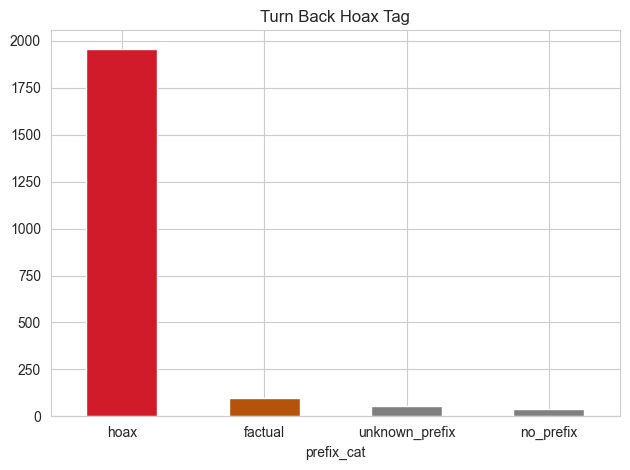

In [ ]:
# fig, axes = plt.subplots(1, 2, figsize=(14, 4))
# prefix_counts.head(10).plot(kind='barh', ax=axes[0], color='steelblue')
# axes[0].set_title('Top 10 turnbackhoax prefixes')
# axes[0].invert_yaxis()
cat_counts.plot(kind='bar', color=['#d11a2a', '#b45309', '#7f7f7f', "#535353"])
plt.title('Turn Back Hoax Tag')
plt.tick_params(axis='x', rotation=0)
plt.tight_layout(); plt.savefig(f'{OUT}/raw_prefix_distribution.png'); plt.show()

### 1.2 Category distribution

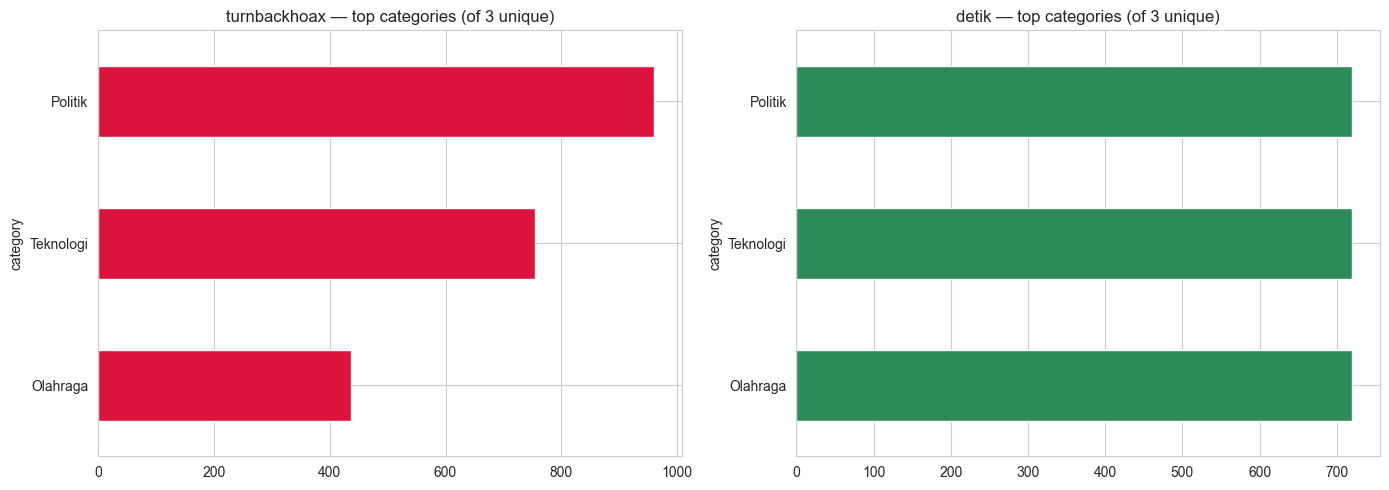

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
tbh_raw['category'].value_counts().head(15).plot(kind='barh', ax=axes[0], color='crimson')
axes[0].set_title(f'turnbackhoax — top categories (of {tbh_raw["category"].nunique()} unique)')
axes[0].invert_yaxis()
det_raw['category'].value_counts().head(15).plot(kind='barh', ax=axes[1], color='seagreen')
axes[1].set_title(f'detik — top categories (of {det_raw["category"].nunique()} unique)')
axes[1].invert_yaxis()
plt.tight_layout(); plt.savefig(f'{OUT}/raw_category_distribution.png'); plt.show()

### 1.3 Date / temporal coverage

### 1.4 Raw title length

In [24]:
tbh_raw['title_chars'] = tbh_raw['title'].astype(str).str.len()
tbh_raw['title_words'] = tbh_raw['title'].astype(str).str.split().str.len()
det_raw['title_chars'] = det_raw['title'].astype(str).str.len()
det_raw['title_words'] = det_raw['title'].astype(str).str.split().str.len()

stats = pd.DataFrame({
    'tbh_chars': tbh_raw['title_chars'].describe(),
    'det_chars': det_raw['title_chars'].describe(),
    'tbh_words': tbh_raw['title_words'].describe(),
    'det_words': det_raw['title_words'].describe(),
}).round(1)
stats

,tbh_chars,det_chars,tbh_words,det_words
count,2152.0,2160.0,2152.0,2160.0
mean,72.3,64.2,10.4,9.7
std,24.1,10.1,3.6,1.8
min,5.0,14.0,1.0,2.0
25%,54.0,58.0,8.0,9.0
50%,70.0,66.0,10.0,10.0
75%,87.0,72.0,12.0,11.0
max,232.0,89.0,33.0,15.0


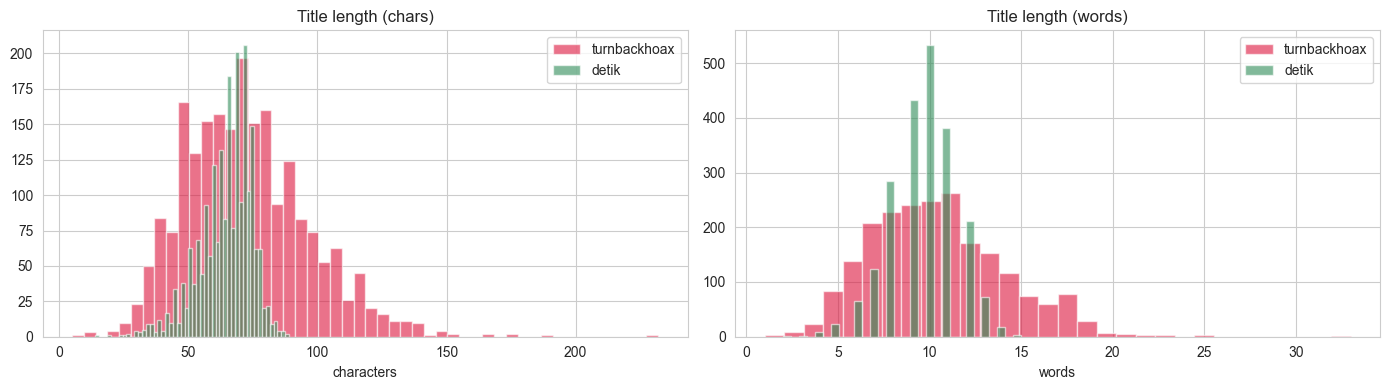

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(tbh_raw['title_chars'], bins=50, alpha=0.6, label='turnbackhoax', color='crimson')
axes[0].hist(det_raw['title_chars'], bins=50, alpha=0.6, label='detik', color='seagreen')
axes[0].set_xlabel('characters'); axes[0].set_title('Title length (chars)'); axes[0].legend()
axes[1].hist(tbh_raw['title_words'].dropna(), bins=30, alpha=0.6, label='turnbackhoax', color='crimson')
axes[1].hist(det_raw['title_words'].dropna(), bins=30, alpha=0.6, label='detik', color='seagreen')
axes[1].set_xlabel('words'); axes[1].set_title('Title length (words)'); axes[1].legend()
plt.tight_layout(); plt.savefig(f'{OUT}/raw_title_length.png'); plt.show()

## 1.5 Word Cloud — Merged Pre-Split Corpus

Mirror the merge logic from [src/preprocess.py](../src/preprocess.py): turnbackhoax (filtered by `[PREFIX]`) **+** detik (all factual) **+** dedup, tapi **belum** di-split. Word cloud dibuat dari sini supaya distribusi kata merefleksikan seluruh korpus, bukan satu split tertentu.

Butuh package `wordcloud`: `pip install wordcloud`

In [ ]:
# Reproduksi pipeline preprocess.py s/d sebelum train/test split
def general_clean(text):
    text = str(text)
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^\x00-\x7FÀ-ɏ]+', ' ', text)
    return re.sub(r'\s+', ' ', text).strip()

def extract_label_and_text(text):
    m = re.search(r'\[([A-Z\s]+)\]', str(text), re.IGNORECASE)
    if m:
        tag = m.group(1).upper().strip()
        if tag in HOAX_PREFIXES: label = 1
        elif tag in REAL_PREFIXES: label = 0
        else: label = -1
    else:
        label = -1
    clean = re.sub(r'\[.*?\]', '', str(text)).strip()
    return label, clean

# --- turnbackhoax ---
tbh = pd.read_csv('data/raw/turnbackhoax.csv')
tbh.columns = tbh.columns.str.lower()
tbh = tbh.dropna(subset=['title']).copy()
tbh['title'] = tbh['title'].apply(general_clean)
tbh[['label', 'title']] = tbh['title'].apply(lambda t: pd.Series(extract_label_and_text(t)))
tbh = tbh[tbh['label'] != -1].copy()

# --- detik (semua factual) ---
det = pd.read_csv('data/raw/detik.csv')
det.columns = det.columns.str.lower()
det = det.dropna(subset=['title']).copy()
det['title'] = det['title'].apply(general_clean)
det['label'] = 0

# --- gabung + dedup (sama persis seperti preprocess.py) ---
merged = pd.concat([tbh[['title', 'label']], det[['title', 'label']]], ignore_index=True)
before = len(merged)
merged['_norm'] = merged['title'].str.lower().str.strip()
merged = merged.drop_duplicates(subset=['_norm']).drop(columns=['_norm']).reset_index(drop=True)
print(f'Merged corpus (pre-split): {before} -> {len(merged)} rows after dedup')
print(f'Label distribution: {merged["label"].value_counts().to_dict()}')
merged.head(3)

In [ ]:
# Word cloud — masing-masing 1 plot terpisah, warna bold (constrained lightness)
try:
    from wordcloud import WordCloud
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'wordcloud', '-q'])
    from wordcloud import WordCloud

import nltk, random
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

stop_id = set(stopwords.words('indonesian'))
extra_stop = {'yg', 'utk', 'dgn', 'tdk', 'jd', 'sdh', 'krn', 'dr', 'pd', 'spt'}
STOPS = stop_id | extra_stop

def wc_text(series):
    txt = ' '.join(series.astype(str).str.lower().tolist())
    txt = re.sub(r'[^a-z\s]', ' ', txt)
    return ' '.join(w for w in txt.split() if w not in STOPS and len(w) > 2)

all_txt  = wc_text(merged['title'])
hoax_txt = wc_text(merged.loc[merged['label'] == 1, 'title'])
fact_txt = wc_text(merged.loc[merged['label'] == 0, 'title'])

# Custom color funcs — pakai HSL dengan lightness terbatas di range gelap (20-45%)
# biar semua kata (besar/kecil) tetap punya warna pekat & terbaca
def make_color_func(hue_range, sat_range=(70, 95), light_range=(25, 45)):
    rng = random.Random(42)
    def color_func(word, font_size, position, orientation, font_path, random_state):
        h = rng.randint(*hue_range)
        s = rng.randint(*sat_range)
        l = rng.randint(*light_range)
        return f"hsl({h}, {s}%, {l}%)"
    return color_func

color_funcs = {
    'all':     make_color_func(hue_range=(100, 180)),   # green-teal
    'hoax':    make_color_func(hue_range=(0, 20)),      # red-orange
    'factual': make_color_func(hue_range=(200, 230)),   # blue
}

def make_wc(text, color_func):
    return WordCloud(
        width=1200, height=600, background_color='white',
        max_words=150, collocations=False,
        random_state=42, color_func=color_func,
        prefer_horizontal=0.9
    ).generate(text)

for title, txt, key, fname in [
    ('All (merged pre-split)', all_txt,  'all',     'wordcloud_all.png'),
    ('Hoax (label=1)',         hoax_txt, 'hoax',    'wordcloud_hoax.png'),
    ('Faktual (label=0)',      fact_txt, 'factual', 'wordcloud_factual.png'),
]:
    plt.figure(figsize=(12, 6))
    plt.imshow(make_wc(txt, color_funcs[key]), interpolation='bilinear')
    plt.title(title, fontsize=14, fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    plt.savefig(f'{OUT}/{fname}', dpi=120, bbox_inches='tight')
    plt.show()

In [ ]:
# Distinctive tokens — kata yang mencolok di salah satu kelas saja
hoax_tokens = Counter(hoax_txt.split())
fact_tokens = Counter(fact_txt.split())

# Log-ratio: positif = lebih kuat di hoax, negatif = lebih kuat di faktual
vocab_shared = set(hoax_tokens) | set(fact_tokens)
rows = []
for w in vocab_shared:
    h = hoax_tokens.get(w, 0) + 1   # laplace smoothing
    f = fact_tokens.get(w, 0) + 1
    if h + f < 10:                  # skip kata terlalu jarang
        continue
    rows.append({'word': w, 'hoax': h-1, 'factual': f-1,
                 'log_ratio': np.log(h / f)})
ratio_df = pd.DataFrame(rows).sort_values('log_ratio')

print('Top 15 kata khas FAKTUAL:'); print(ratio_df.head(15).to_string(index=False))
print('\nTop 15 kata khas HOAX:'); print(ratio_df.tail(15).iloc[::-1].to_string(index=False))

## 2. Processed Data — Pipeline A & B Splits

In [26]:
def load_pipeline(name):
    base = f'data/processed/{name}'
    if not os.path.exists(base):
        print(f'MISSING {base}'); return None
    return {
        split: pd.read_csv(f'{base}/{split}.csv') for split in ('train', 'val', 'test')
    }

pa = load_pipeline('pipeline_a')
pb = load_pipeline('pipeline_b')

rows = []
for pname, p in [('pipeline_a', pa), ('pipeline_b', pb)]:
    if p is None: continue
    for split, df in p.items():
        n_hoax = int((df['label'] == 1).sum())
        n_fact = int((df['label'] == 0).sum())
        rows.append({'pipeline': pname, 'split': split, 'rows': len(df),
                     'hoax': n_hoax, 'factual': n_fact,
                     'pct_hoax': round(100 * n_hoax / len(df), 1)})
split_summary = pd.DataFrame(rows)
split_summary

,pipeline,split,rows,hoax,factual,pct_hoax
0,pipeline_a,train,2737,1213,1524,44.3
1,pipeline_a,val,391,174,217,44.5
2,pipeline_a,test,783,347,436,44.3
3,pipeline_b,train,2737,1213,1524,44.3
4,pipeline_b,val,391,174,217,44.5
5,pipeline_b,test,783,347,436,44.3


### 2.1 Class balance per split

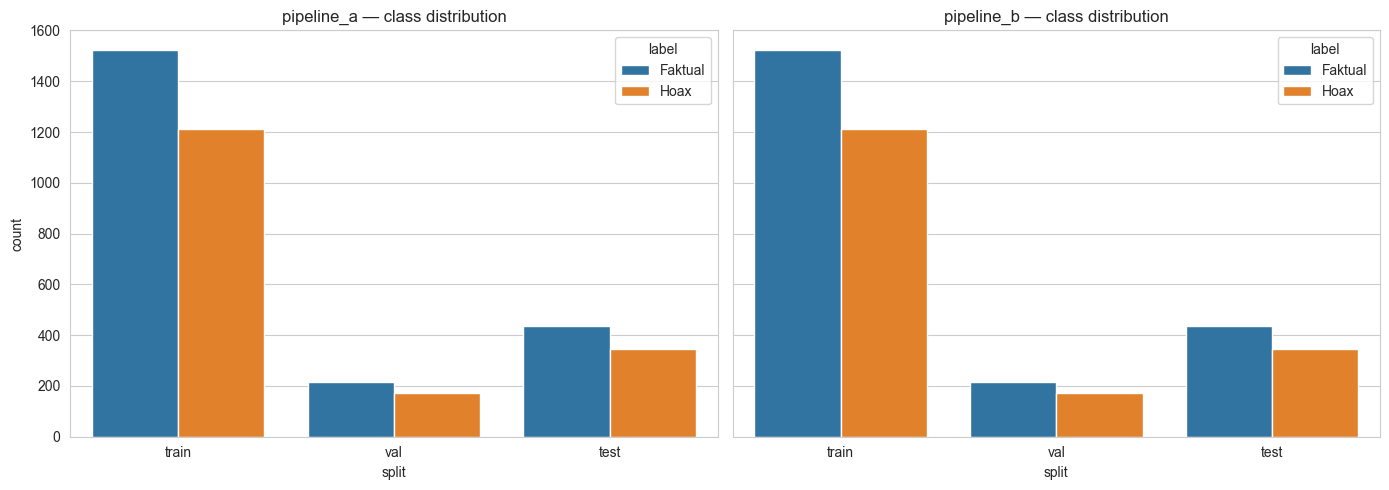

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, (pname, p) in zip(axes, [('pipeline_a', pa), ('pipeline_b', pb)]):
    if p is None: continue
    plot_rows = []
    for split, df in p.items():
        for lab, cnt in df['label'].value_counts().items():
            plot_rows.append({'split': split, 'label': 'Hoax' if lab == 1 else 'Faktual', 'count': cnt})
    plot_df = pd.DataFrame(plot_rows)
    sns.barplot(data=plot_df, x='split', y='count', hue='label',
                palette=['#1f77b4', '#ff7f0e'], ax=ax, order=['train', 'val', 'test'])
    ax.set_title(f'{pname} — class distribution')
plt.tight_layout(); plt.savefig(f'{OUT}/processed_class_balance.png'); plt.show()

### 2.2 Text length per split (post-cleaning)

Pipeline A is aggressively cleaned (lowercase, punct stripped, stopwords removed) so it should be shorter than Pipeline B.

In [28]:
def length_stats(p):
    if p is None: return None
    rows = []
    for split, df in p.items():
        wl = df['text'].astype(str).str.split().str.len()
        rows.append({'split': split, 'mean_words': wl.mean(), 'median': wl.median(),
                     'p95': wl.quantile(.95), 'max': wl.max()})
    return pd.DataFrame(rows).round(1)

print('Pipeline A (cleaned for TF-IDF / BiLSTM):'); print(length_stats(pa)); print()
print('Pipeline B (raw for IndoBERT):'); print(length_stats(pb))

Pipeline A (cleaned for TF-IDF / BiLSTM):
   split  mean_words  median   p95  max
0  train         7.2     7.0  11.0   22
1    val         7.2     7.0  11.0   16
2   test         7.0     7.0  10.0   16

Pipeline B (raw for IndoBERT):
   split  mean_words  median   p95  max
0  train         9.6    10.0  14.0   32
1    val         9.7     9.0  14.5   23
2   test         9.5    10.0  14.0   24


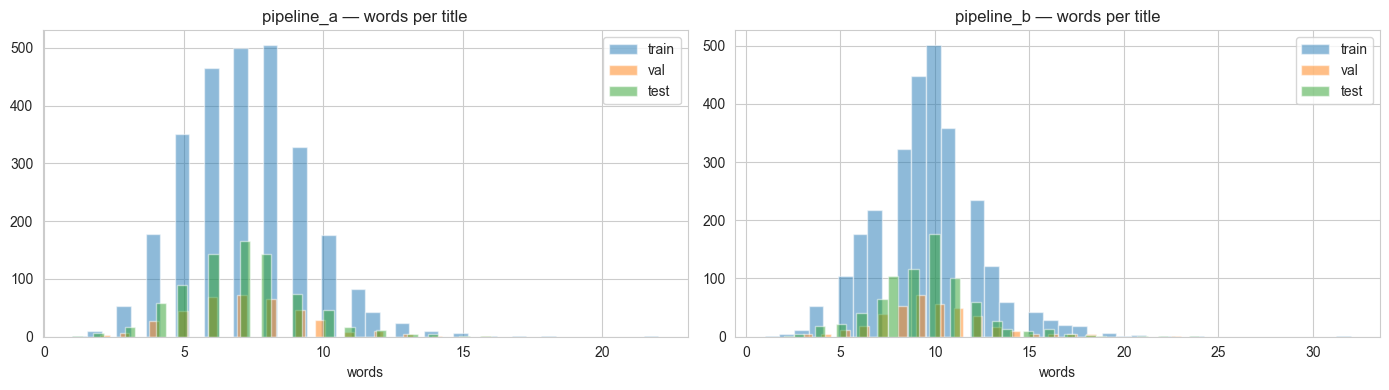

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, (pname, p) in zip(axes, [('pipeline_a', pa), ('pipeline_b', pb)]):
    if p is None: continue
    for split, df in p.items():
        wl = df['text'].astype(str).str.split().str.len()
        ax.hist(wl, bins=40, alpha=0.5, label=split)
    ax.set_title(f'{pname} — words per title'); ax.set_xlabel('words'); ax.legend()
plt.tight_layout(); plt.savefig(f'{OUT}/processed_text_length.png'); plt.show()

### 2.3 Length by class (hoax vs factual)

If hoax titles are consistently longer/shorter, simple length is already a leak signal.

          count  mean  std  min  25%   50%   75%   max
class                                                 
Faktual  1524.0   9.7  1.9  2.0  9.0  10.0  11.0  19.0
Hoax     1213.0   9.4  3.6  1.0  7.0   9.0  11.0  32.0


C:\Users\Lucky\AppData\Local\Temp\ipykernel_17004\3727412547.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='class', y='words', palette=['#1f77b4', '#ff7f0e'])


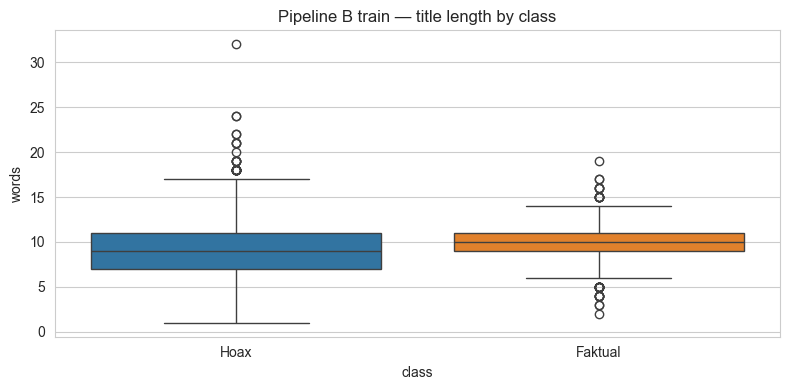

In [30]:
if pb is not None:
    df = pb['train'].copy()
    df['words'] = df['text'].astype(str).str.split().str.len()
    df['class'] = df['label'].map({0: 'Faktual', 1: 'Hoax'})
    print(df.groupby('class')['words'].describe().round(1))
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=df, x='class', y='words', palette=['#1f77b4', '#ff7f0e'])
    plt.title('Pipeline B train — title length by class')
    plt.tight_layout(); plt.savefig(f'{OUT}/processed_length_by_class.png'); plt.show()

### 2.4 Vocabulary stats (Pipeline A train)

tokens total : 19,736
vocab unique : 6,828
singletons   : 4,013


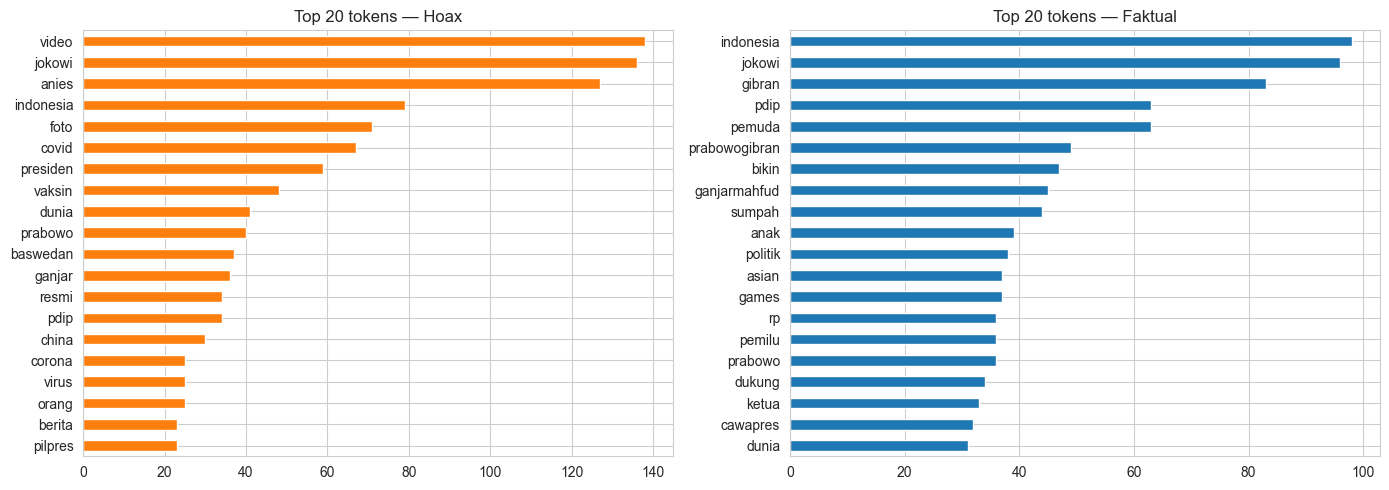

In [31]:
if pa is not None:
    train_text = pa['train']['text'].astype(str)
    all_tokens = [t for line in train_text for t in line.split()]
    vocab = Counter(all_tokens)
    print(f'tokens total : {len(all_tokens):,}')
    print(f'vocab unique : {len(vocab):,}')
    print(f'singletons   : {sum(1 for v in vocab.values() if v == 1):,}')

    hoax_tok    = Counter(t for txt, lab in zip(train_text, pa['train']['label']) if lab == 1 for t in txt.split())
    factual_tok = Counter(t for txt, lab in zip(train_text, pa['train']['label']) if lab == 0 for t in txt.split())

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    pd.Series(dict(hoax_tok.most_common(20))).plot(kind='barh', ax=axes[0], color='#ff7f0e')
    axes[0].set_title('Top 20 tokens — Hoax'); axes[0].invert_yaxis()
    pd.Series(dict(factual_tok.most_common(20))).plot(kind='barh', ax=axes[1], color='#1f77b4')
    axes[1].set_title('Top 20 tokens — Faktual'); axes[1].invert_yaxis()
    plt.tight_layout(); plt.savefig(f'{OUT}/processed_top_tokens.png'); plt.show()

### 2.5 Leakage check — overlap across splits

`preprocess.py` dedupes *before* splitting, so this should be 0. Verify.

In [32]:
def overlap_check(p, name):
    if p is None: return
    tr = set(p['train']['text'].astype(str).str.lower().str.strip())
    va = set(p['val']['text'].astype(str).str.lower().str.strip())
    te = set(p['test']['text'].astype(str).str.lower().str.strip())
    print(f'{name}:  train-val={len(tr & va)}  train-test={len(tr & te)}  val-test={len(va & te)}')

overlap_check(pa, 'pipeline_a')
overlap_check(pb, 'pipeline_b')

pipeline_a:  train-val=0  train-test=1  val-test=0
pipeline_b:  train-val=0  train-test=0  val-test=0


## 3. Summary

Key things to report:
- **Total final corpus size** after dedup → see `split_summary` above
- **Class ratio** (hoax / factual) per split — confirms stratification worked
- **Rows dropped** by unknown-prefix filter (section 1.1)
- **Length differential** between pipelines (~stopword removal cuts ~40-50%)
- **No cross-split leakage** (section 2.5)

All plots saved to `results/eda/`.